<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week17/day1-2/BaristaBot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -qU --upgrade langgraph langgraph-prebuilt langchain-google-genai google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.1/259.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 6.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.3 which is incompatible.


In [2]:
import os
from google.colab import userdata

GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class OrderState(TypedDict):
    """State representing the customer's order conversation."""

    # The chat conversation. This preserves the conversation history
    # between nodes. The `add_messages` annotation indicates to LangGraph
    # that state is updated by appending returned messages, not replacing
    # them.
    messages: Annotated[list, add_messages]

    # The customer's in-progress order.
    order: list[str]

    # Flag indicating that the order is placed and completed.
    finished: bool
# The system instruction defines how the chatbot is expected to behave and includes
# rules for when to call different functions, as well as rules for the conversation, such
# as tone and what is permitted for discussion.
BARISTABOT_SYSINT = (
    "system",  # 'system' indicates the message is a system instruction.
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user) "
    "Always confirm_order with the user (double-check) before calling place_order. Calling confirm_order will "
    "display the order items to the user and returns their response to seeing the list. Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!",
)

# This is the message with which the system opens the conversation.
WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash")

def chatbot(state: OrderState) -> OrderState:
    """The chatbot itself. A simple wrapper around the model's own chat interface."""
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    return {"messages": [llm.invoke(message_history)]}

graph_builder = StateGraph(OrderState)          # create graph with our state schema
graph_builder.add_node("chatbot", chatbot)       # register the node
graph_builder.add_edge(START, "chatbot")         # entrypoint -> chatbot

chat_graph = graph_builder.compile()             # compile into runnable graph

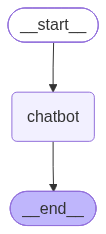

In [5]:
from IPython.display import Image
Image(chat_graph.get_graph().draw_mermaid_png())

In [6]:
from pprint import pprint

user_msg = "Hello, what can you tell me about your teas?"
state = chat_graph.invoke({"messages": [("user", user_msg)]})

for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: Hello, what can you tell me about your teas?
AIMessage: [{'type': 'text', 'text': "Welcome to the cafe! We have a wonderful selection of teas to choose from, whether you're looking for something traditional, spiced, or soothing. Here is what we offer:\n\n* **Earl Grey**: A classic black tea infused with the distinct oil of bergamot citrus. Black tea dates back centuries, and the Earl Grey blend became popular in 19th-century England, named after Prime Minister Charles Grey. It offers a bold, fragrant, and slightly floral flavor.\n* **Chai Latte**: A rich blend of spiced black tea (featuring cinnamon, cardamom, ginger, and cloves) combined with steamed milk. Chai has roots in ancient Indian Ayurvedic traditions before becoming the cozy, spiced milk tea favorite we know today.\n* **Matcha Latte**: Finely ground shade-grown Japanese green tea whisked and combined with milk. Matcha has a rich history tied to traditional Japanese tea ceremonies going back to the 12th century. 

In [7]:
user_msg = "I'd like a latte."

state["messages"].append(("user", user_msg))
state = chat_graph.invoke(state)

for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: Hello, what can you tell me about your teas?
AIMessage: [{'type': 'text', 'text': "Welcome to the cafe! We have a wonderful selection of teas to choose from, whether you're looking for something traditional, spiced, or soothing. Here is what we offer:\n\n* **Earl Grey**: A classic black tea infused with the distinct oil of bergamot citrus. Black tea dates back centuries, and the Earl Grey blend became popular in 19th-century England, named after Prime Minister Charles Grey. It offers a bold, fragrant, and slightly floral flavor.\n* **Chai Latte**: A rich blend of spiced black tea (featuring cinnamon, cardamom, ginger, and cloves) combined with steamed milk. Chai has roots in ancient Indian Ayurvedic traditions before becoming the cozy, spiced milk tea favorite we know today.\n* **Matcha Latte**: Finely ground shade-grown Japanese green tea whisked and combined with milk. Matcha has a rich history tied to traditional Japanese tea ceremonies going back to the 12th century. 

In [8]:
from langchain_core.messages.ai import AIMessage


def human_node(state: OrderState) -> OrderState:
    """Display the last model message to the user, and receive the user's input."""
    last_msg = state["messages"][-1]
    print("Model:", last_msg.content)

    user_input = input("User: ")

    if user_input in {"q", "quit", "exit", "goodbye"}:
        state["finished"] = True

    return state | {"messages": [("user", user_input)]}


def chatbot_with_welcome_msg(state: OrderState) -> OrderState:
    """The chatbot itself. A wrapper around the model's own chat interface."""
    if state["messages"]:
        new_output = llm.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)

    return state | {"messages": [new_output]}


graph_builder = StateGraph(OrderState)

graph_builder.add_node("chatbot", chatbot_with_welcome_msg)
graph_builder.add_node("human", human_node)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", "human")

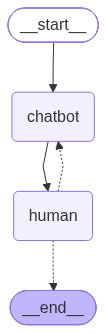

In [9]:
from typing import Literal

def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:
    """Route to the chatbot, unless it looks like the user is exiting."""
    if state.get("finished", False):
        return END
    else:
        return "chatbot"

graph_builder.add_conditional_edges("human", maybe_exit_human_node)

chat_with_human_graph = graph_builder.compile()

Image(chat_with_human_graph.get_graph().draw_mermaid_png())

In [10]:
from langchain_core.tools import tool


@tool
def get_menu() -> str:
    """Provide the latest up-to-date menu."""
    # Note that this is just hard-coded text, but you could connect this to a live stock
    # database, or you could use Gemini's multi-modal capabilities and take live photos of
    # your cafe's chalk menu or the products on the counter and assmble them into an input.

    return """
    MENU:
    Coffee Drinks:
    Espresso
    Americano
    Cold Brew

    Coffee Drinks with Milk:
    Latte
    Cappuccino
    Cortado
    Macchiato
    Mocha
    Flat White

    Tea Drinks:
    English Breakfast Tea
    Green Tea
    Earl Grey

    Tea Drinks with Milk:
    Chai Latte
    Matcha Latte
    London Fog

    Other Drinks:
    Steamer
    Hot Chocolate
Modifiers:
    Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free; Default option: whole
    Espresso shots: Single, Double, Triple, Quadruple; default: Double
    Caffeine: Decaf, Regular; default: Regular
    Hot-Iced: Hot, Iced; Default: Hot
    Sweeteners (option to add one or more): vanilla sweetener, hazelnut sweetener, caramel sauce, chocolate sauce, sugar free vanilla sweetener
    Special requests: any reasonable modification that does not involve items not on the menu, for example: 'extra hot', 'one pump', 'half caff', 'extra foam', etc.

    "dirty" means add a shot of espresso to a drink that doesn't usually have it, like "Dirty Chai Latte".
    "Regular milk" is the same as 'whole milk'.
    "Sweetened" means add some regular sugar, not a sweetener.

    Soy milk has run out of stock today, so soy is not available.
  """

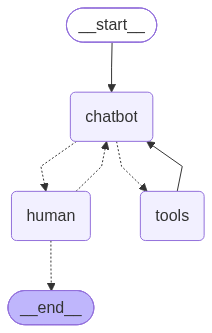

In [11]:
from langgraph.prebuilt import ToolNode

tools = [get_menu]
tool_node = ToolNode(tools)

llm_with_tools = llm.bind_tools(tools)

def maybe_route_to_tools(state: OrderState) -> Literal["tools", "human"]:
    """Route between human or tool nodes, depending if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")
    msg = msgs[-1]
    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        return "tools"
    else:
        return "human"

def chatbot_with_tools(state: OrderState) -> OrderState:
    """The chatbot with tools. A simple wrapper around the model's own chat interface."""
    defaults = {"order": [], "finished": False}
    if state["messages"]:
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)
    return defaults | state | {"messages": [new_output]}

graph_builder = StateGraph(OrderState)

graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph_with_menu = graph_builder.compile()

Image(graph_with_menu.get_graph().draw_mermaid_png())

In [13]:
from collections.abc import Iterable
from random import randint

from langgraph.prebuilt import InjectedState
from langchain_core.messages.tool import ToolMessage


@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Adds the specified drink to the customer's order, including any modifiers.

    Returns:
      The updated order in progress.
    """


@tool
def confirm_order() -> str:
    """Asks the customer if the order is correct.

    Returns:
      The user's free-text response.
    """


@tool
def get_order() -> str:
    """Returns the users order so far. One item per line."""


@tool
def clear_order():
    """Removes all items from the user's order."""


@tool
def place_order() -> int:
    """Sends the order to the barista for fulfillment.

    Returns:
      The estimated number of minutes until the order is ready.
    """


def order_node(state: OrderState) -> OrderState:
    """The ordering node. This is where the order state is manipulated."""
    tool_msg = state["messages"][-1]
    order = state.get("order", [])
    outbound_msgs = []
    order_placed = False

    for tool_call in tool_msg.tool_calls:

        if tool_call["name"] == "add_to_order":
            modifiers = tool_call["args"]["modifiers"]
            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"
            order.append(f'{tool_call["args"]["drink"]} ({modifier_str})')
            response = "\n".join(order)

        elif tool_call["name"] == "confirm_order":
            print("Your order:")
            if not order:
                print("  (no items)")
            for drink in order:
                print(f"  {drink}")
            response = input("Is this correct? ")

        elif tool_call["name"] == "get_order":
            response = "\n".join(order) if order else "(no order)"

        elif tool_call["name"] == "clear_order":
            order.clear()
            response = None

        elif tool_call["name"] == "place_order":
            order_text = "\n".join(order)
            print("Sending order to kitchen!")
            print(order_text)
            order_placed = True
            response = randint(1, 5)  # ETA in minutes

        else:
            raise NotImplementedError(f'Unknown tool call: {tool_call["name"]}')

        outbound_msgs.append(
            ToolMessage(
                content=response,
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}


def maybe_route_to_tools(state: OrderState) -> str:
    """Route between chat and tool nodes if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    msg = msgs[-1]

    if state.get("finished", False):
        return END

    elif hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        if any(
            tool["name"] in tool_node.tools_by_name.keys() for tool in msg.tool_calls
        ):
            return "tools"
        else:
            return "ordering"

    else:
        return "human"

In [14]:
def order_node(state: OrderState) -> OrderState:
    """The ordering node. This is where the order state is manipulated."""
    tool_msg = state["messages"][-1]
    order = state.get("order", [])
    outbound_msgs = []
    order_placed = False

    for tool_call in tool_msg.tool_calls:

        if tool_call["name"] == "add_to_order":
            modifiers = tool_call["args"]["modifiers"]
            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"
            order.append(f'{tool_call["args"]["drink"]} ({modifier_str})')
            response = "\n".join(order)

        elif tool_call["name"] == "confirm_order":
            print("Your order:")
            if not order:
                print("  (no items)")
            for drink in order:
                print(f"  {drink}")
            response = input("Is this correct? ")

        elif tool_call["name"] == "get_order":
            response = "\n".join(order) if order else "(no order)"

        elif tool_call["name"] == "clear_order":
            order.clear()
            response = None

        elif tool_call["name"] == "place_order":
            order_text = "\n".join(order)
            print("Sending order to kitchen!")
            print(order_text)
            order_placed = True
            response = randint(1, 5)

        else:
            raise NotImplementedError(f'Unknown tool call: {tool_call["name"]}')

        outbound_msgs.append(
            ToolMessage(
                content=response,
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}

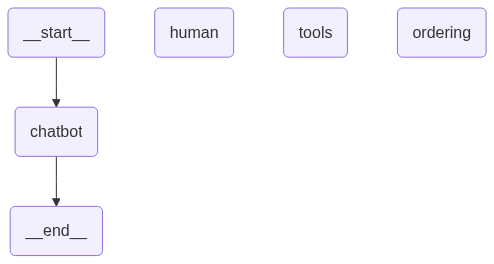

In [15]:
# Auto-tools will be invoked automatically by the ToolNode
auto_tools = [get_menu]
tool_node = ToolNode(auto_tools)

# Order-tools will be handled by the order node
order_tools = [add_to_order, confirm_order, get_order, clear_order, place_order]

# LLM needs to know about all tools
llm_with_tools = llm.bind_tools(auto_tools + order_tools)


graph_builder = StateGraph(OrderState)

graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("ordering", order_node)

graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("ordering", "chatbot")

graph_builder.add_edge(START, "chatbot")
graph_with_order_tools = graph_builder.compile()

Image(graph_with_order_tools.get_graph().draw_mermaid_png())

In [ ]:
config = {"recursion_limit": 100}
state = graph_with_order_tools.invoke({"messages": []}, config)
pprint(state)

Model: Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?
User: I want a coffee
Model: [{'type': 'text', 'text': "We have several coffee options available! \n\n**Black Coffee Drinks:**\n- Espresso\n- Americano\n- Cold Brew\n\n**Milk Coffee Drinks:**\n- Latte\n- Cappuccino\n- Cortado\n- Macchiato\n- Mocha\n- Flat White\n\nWhich kind of coffee would you like? Also, let me know if you'd like any specific milk (Whole, 2%, Oat, Almond, 2% Lactose Free), size/shots, caffeine level (Regular/Decaf), hot/iced, or flavored sweeteners!", 'extras': {'signature': 'EvUDCvIDARFNMg/KWV+VBHSnCt6z1J36s/7/GhWpva83jTIokTIm8tMYWEWcUVdcggjyANVSQr6ITymY8D7e8+UwsycHAeasrHp+ciPwXyP5sgu2eOnwHbKPMQbcWg6HhMyn71bP+vFX1QJEqHQ49ZNmKex2+z3R0B7V8ZGND/oXI7Zgi71UJ9CRP6jBaUrC1D3ZUZViU2AGdvykrJrBGP2vm6tveWa5xSjrAvUMRtju4saExzAux6zrG2EmXyNB0kQH/SizradNEON5rkauzecXS3e/UBgTwiI00G+nH/EE0T1P7NP24V4CHZtlFnwncJ8C9P24RDqNKlmrQMjDRbrpSjyi4OLUqezpPzMuHy8ntODK/gjoJhW3gNvbNgvpEk2VX4NXU98d2Z3y0ZU81UwCMnlwmtqj